In [158]:
#from music21 import configure
#configure.run()

In [159]:
from music21 import converter
# Load MusicXML file
score = converter.parse('Liz_and_the_Blue_Bird_III-pt_A.mxl')
# Print score structure
#for part in score.parts:
  #print(part.id)

In [160]:
#!cp /usr/bin/mscore /usr/bin/mscore3

In [161]:
import ms3
# Need to link /usr/bin/mscore to /usr/bin/mscore3
#score.show()

In [162]:
"""
def delete_first_beats(xml_score, start_measure, start_beat):
    xml_score = copy.deepcopy(xml_score)
    start_offset = start_beat - 1
    for measure in xml_score.recurse(classFilter=('Measure')):
        if measure.number == start_measure:
            removed = set()
            for note_or_rest in measure.recurse(classFilter=('Note', 'Rest')):
                if note_or_rest.offset < start_offset:
                    removed.add(note_or_rest.activeSite)
                    note_or_rest.activeSite.remove(note_or_rest)
            for stream in removed: stream.insert(0, note.Rest())
    return xml_score
"""

"\ndef delete_first_beats(xml_score, start_measure, start_beat):\n    xml_score = copy.deepcopy(xml_score)\n    start_offset = start_beat - 1\n    for measure in xml_score.recurse(classFilter=('Measure')):\n        if measure.number == start_measure:\n            removed = set()\n            for note_or_rest in measure.recurse(classFilter=('Note', 'Rest')):\n                if note_or_rest.offset < start_offset:\n                    removed.add(note_or_rest.activeSite)\n                    note_or_rest.activeSite.remove(note_or_rest)\n            for stream in removed: stream.insert(0, note.Rest())\n    return xml_score\n"

In [163]:
import copy
from music21 import *
copyScore = copy.deepcopy(score)
stream = copyScore.recurse(classFilter=('Measure'))

#copyScore.show()
for index, measure in enumerate(stream):
  #print(note, note.offset, note.isChord, note.isNote)
  #print(index, measure)
  removed = set()
  for noteObj in measure.recurse(classFilter=('Note', 'Chord')):
    #print(noteObj, noteObj.offset, noteObj.isChord, noteObj.isNote)
    if noteObj.isChord:
      removed.add(noteObj.activeSite)
      noteObj.activeSite.remove(noteObj)
      #print(noteObj.pitches, measure.getInstrument().partName)
      
        #print(noteObj, noteObj.offset, noteObj.isChord, noteObj.isNote)
  #for stream in removed: stream.insert(0, note.Rest())
  #  pass
  #else:
  #  pass
    #print("pop symbol at", index, note)
    #stream.pop(index)
#copyScore.show()


In [164]:
# Start from here

In [165]:
import numpy as np
copyScore2 = copy.deepcopy(copyScore)
stream = copyScore2.recurse(classFilter=('Measure'))

keep_parts = 2

measure_count = 0
#print(copyScore2.parts[0].partName)

measure_loudness = {part.partName: [] for part in copyScore2.parts}
measure_pitch_height = {part.partName: [] for part in copyScore2.parts}
measure_pitch_delta = {part.partName: [] for part in copyScore2.parts}
measure_rhythm_length = {part.partName: [] for part in copyScore2.parts}
measure_accent = {part.partName: [] for part in copyScore2.parts}

weights = np.array([0.2, 0.15, 0.15, 0.2, 0.2, 0.1])

measures = [measure_loudness, measure_pitch_height, measure_pitch_delta, measure_rhythm_length, measure_accent]
#class Measures(Enum):
#    measure_loudness = 1
#    measure_pitch_height = 2
#    measure_pitch_delta = 3
#    measure_rhythm_length = 4
    
def fetch_feature_vector_by_measure(feature, measure_idx, part_list=copyScore2.parts):
    vector = []
    for p in part_list:
        vector.append(measures[feature][p][measure_idx])
    return vector

def write_feature_vector_by_measure(vector, feature, measure_idx, part_list=copyScore2.parts):
    for i,p in enumerate(part_list):
        measures[feature][p][measure_idx] = vector[i]
    

In [166]:
# Feature Vector Extraction
# Find volume at each measure
for index, measure in enumerate(stream):
  max_loudness = 0.
  max_note = pitch.Pitch('A0')
  min_note = pitch.Pitch('G9')
  short_note = 0
  accented = False
  
    #print(measure.measureNumber)
  part = measure.getInstrument().partName

  if measure.measureNumber > measure_count: measure_count = measure.measureNumber
  for noteObj in measure.recurse(classFilter=('Note')):
    if noteObj.volume.getRealized() > max_loudness:
      max_loudness = noteObj.volume.getRealized()
    if noteObj.duration.quarterLength <= 1.0:
        short_note = 1
    if noteObj.pitch < min_note:
        min_note = noteObj.pitch
    if noteObj.pitch > max_note:
        max_note = noteObj.pitch
    if noteObj.articulations is not False:
        accented = True
    #print(measure.measureNumber, noteObj.pitch, part)
        

  # Should just iterate through measure by measure in each part so append works here
  #print(measure.measureNumber)
  measure_loudness[part].append(max_loudness)
  measure_pitch_height[part].append(max_note)
  measure_pitch_delta[part].append(max_note.ps-min_note.ps)
  measure_rhythm_length[part].append(short_note)
  measure_accent[part].append(accented)

In [167]:
#print(pitch.Pitch('C_1').ps)

In [168]:
import statistics
# music21.search.segment

#print(measure_loudness)
#copyScore.show()

parts_to_keep = []
training_parts = []
def mode_check(array):
    mode = statistics.mode(array)
    counter = 0
    for val in array:
        if val == mode: counter+=1
        if counter > 1: return True
    return False

def normalize(array, mode = 0, nonneg = 0):
    aNorm = []
    if nonneg:
      for i,a in enumerate(array):
        if a < 0:
          array[i] = 0
    
    aMax = max(array)
    aMode = statistics.mode(array) if mode_check(array) else statistics.mean(array)
    if mode: # Above mode or is max set to 1, otw 0
      aNorm = [a > aMode or a == aMax for a in array]
    else:
      if aMax > 0:
        aNorm = [a/aMax for a in array]
      else:
        aNorm = [0 for a in array]
    return aNorm

# Post Processing to normalize score
for i in range(0, measure_count):
  volumes = []
  pitches = []
  deltas = []
  rhythms = []
  accents = []
  continuity = []

  # Normalize to 0-1
  for part in copyScore2.parts:
    volumes.append(measure_loudness[part.partName][i])
    pitches.append(measure_pitch_height[part.partName][i])
    deltas.append(measure_pitch_delta[part.partName][i])
    rhythms.append(measure_rhythm_length[part.partName][i])
    accents.append(measure_accent[part.partName][i])

    
    if len(parts_to_keep) > 0:
        last_parts = []
        for j in range(keep_parts):
          last_parts.append(parts_to_keep[i-1][j][1])
        if part.partName in last_parts:
          continuity.append(1)
        else:
          continuity.append(0)
    else: 
      continuity.append(0)
        
  volNorm = normalize(volumes, mode=1)
  pitchNorm = normalize(pitches, mode=1)
  deltaNorm = normalize(deltas, mode=0, nonneg=1)
      
  # Filtering
  score = []
  training_pairs = {}
  for idx, part in enumerate(copyScore2.parts):
      raw_feature = np.array([volumes[idx], pitches[idx], deltas[idx], rhythms[idx], accents[idx], continuity[idx]])
      feature = np.array([volNorm[idx], pitchNorm[idx], deltaNorm[idx], rhythms[idx], accents[idx], continuity[idx]])
      
      training_pairs[part.partName] = feature
      
      score.append((feature@weights, part.partName))
      #print(raw_feature, feature, score[-1], part.partName, i)
  
  score = sorted(score, reverse=True)

  parts_to_keep.append(score[0:keep_parts])

  # For Training
  add_training_part = []
  for j in range(keep_parts):
    add_training_part.append(training_pairs[score[j][1]])
  training_parts.append(add_training_part)

#print(parts_to_keep)
#copyScore2.show()
#print(measure_loudness)
#print(parts_to_keep)



#copyScore2.show()
#print(measure_loudness)
#print(parts_to_keep)


In [169]:
for index, measure in enumerate(stream):
  removed = set()
  keep_list = []
  for i in range(keep_parts):
      keep_list.append(parts_to_keep[measure.measureNumber-1][i][1])
  if measure.getInstrument().partName in keep_list:
    for noteObj in measure.recurse(classFilter=('Note', 'Chord')):
        noteObj.style.color = 'red'

"""
  else:
    #print(parts_to_keep[measure.measureNumber-1][1])
    for noteObj in measure.recurse(classFilter=('Note', 'Chord')):
      removed.add(noteObj.activeSite)
      noteObj.activeSite.remove(noteObj)
      #print(noteObj, noteObj.offset, noteObj.isChord, noteObj.isNote)
""" 
#copyScore2.show()

"\n  else:\n    #print(parts_to_keep[measure.measureNumber-1][1])\n    for noteObj in measure.recurse(classFilter=('Note', 'Chord')):\n      removed.add(noteObj.activeSite)\n      noteObj.activeSite.remove(noteObj)\n      #print(noteObj, noteObj.offset, noteObj.isChord, noteObj.isNote)\n"

In [170]:
#print(type(copyScore2))
#copyScore2.write('musicxml', fp='testLizIII.mxl')

In [171]:
print(parts_to_keep[4:7])

[[(0.9999999999999999, 'Oboe'), (0.6666666666666666, 'Flute 1')], [(0.9999999999999999, 'Oboe'), (0.8785714285714286, 'Alto Saxophone')], [(0.9357142857142856, 'Oboe'), (0.8999999999999999, 'Harp')]]


In [172]:
# Pickups and drop-afters
last_measure = None
for index, measure in enumerate(stream):
  keep_list = []
  for i in range(keep_parts):
      keep_list.append(parts_to_keep[measure.measureNumber-1][i][1])
  if measure.getInstrument().partName in keep_list:
      if last_measure is not None:
          for noteObj in last_measure.recurse(classFilter=('Note', 'Chord')):
              if noteObj.style.color != 'red':
                  noteObj.style.color = 'green'
    #for noteObj in measure.recurse(classFilter=('Note', 'Chord')):
    #    noteObj.style.color = 'red'
  last_measure = measure

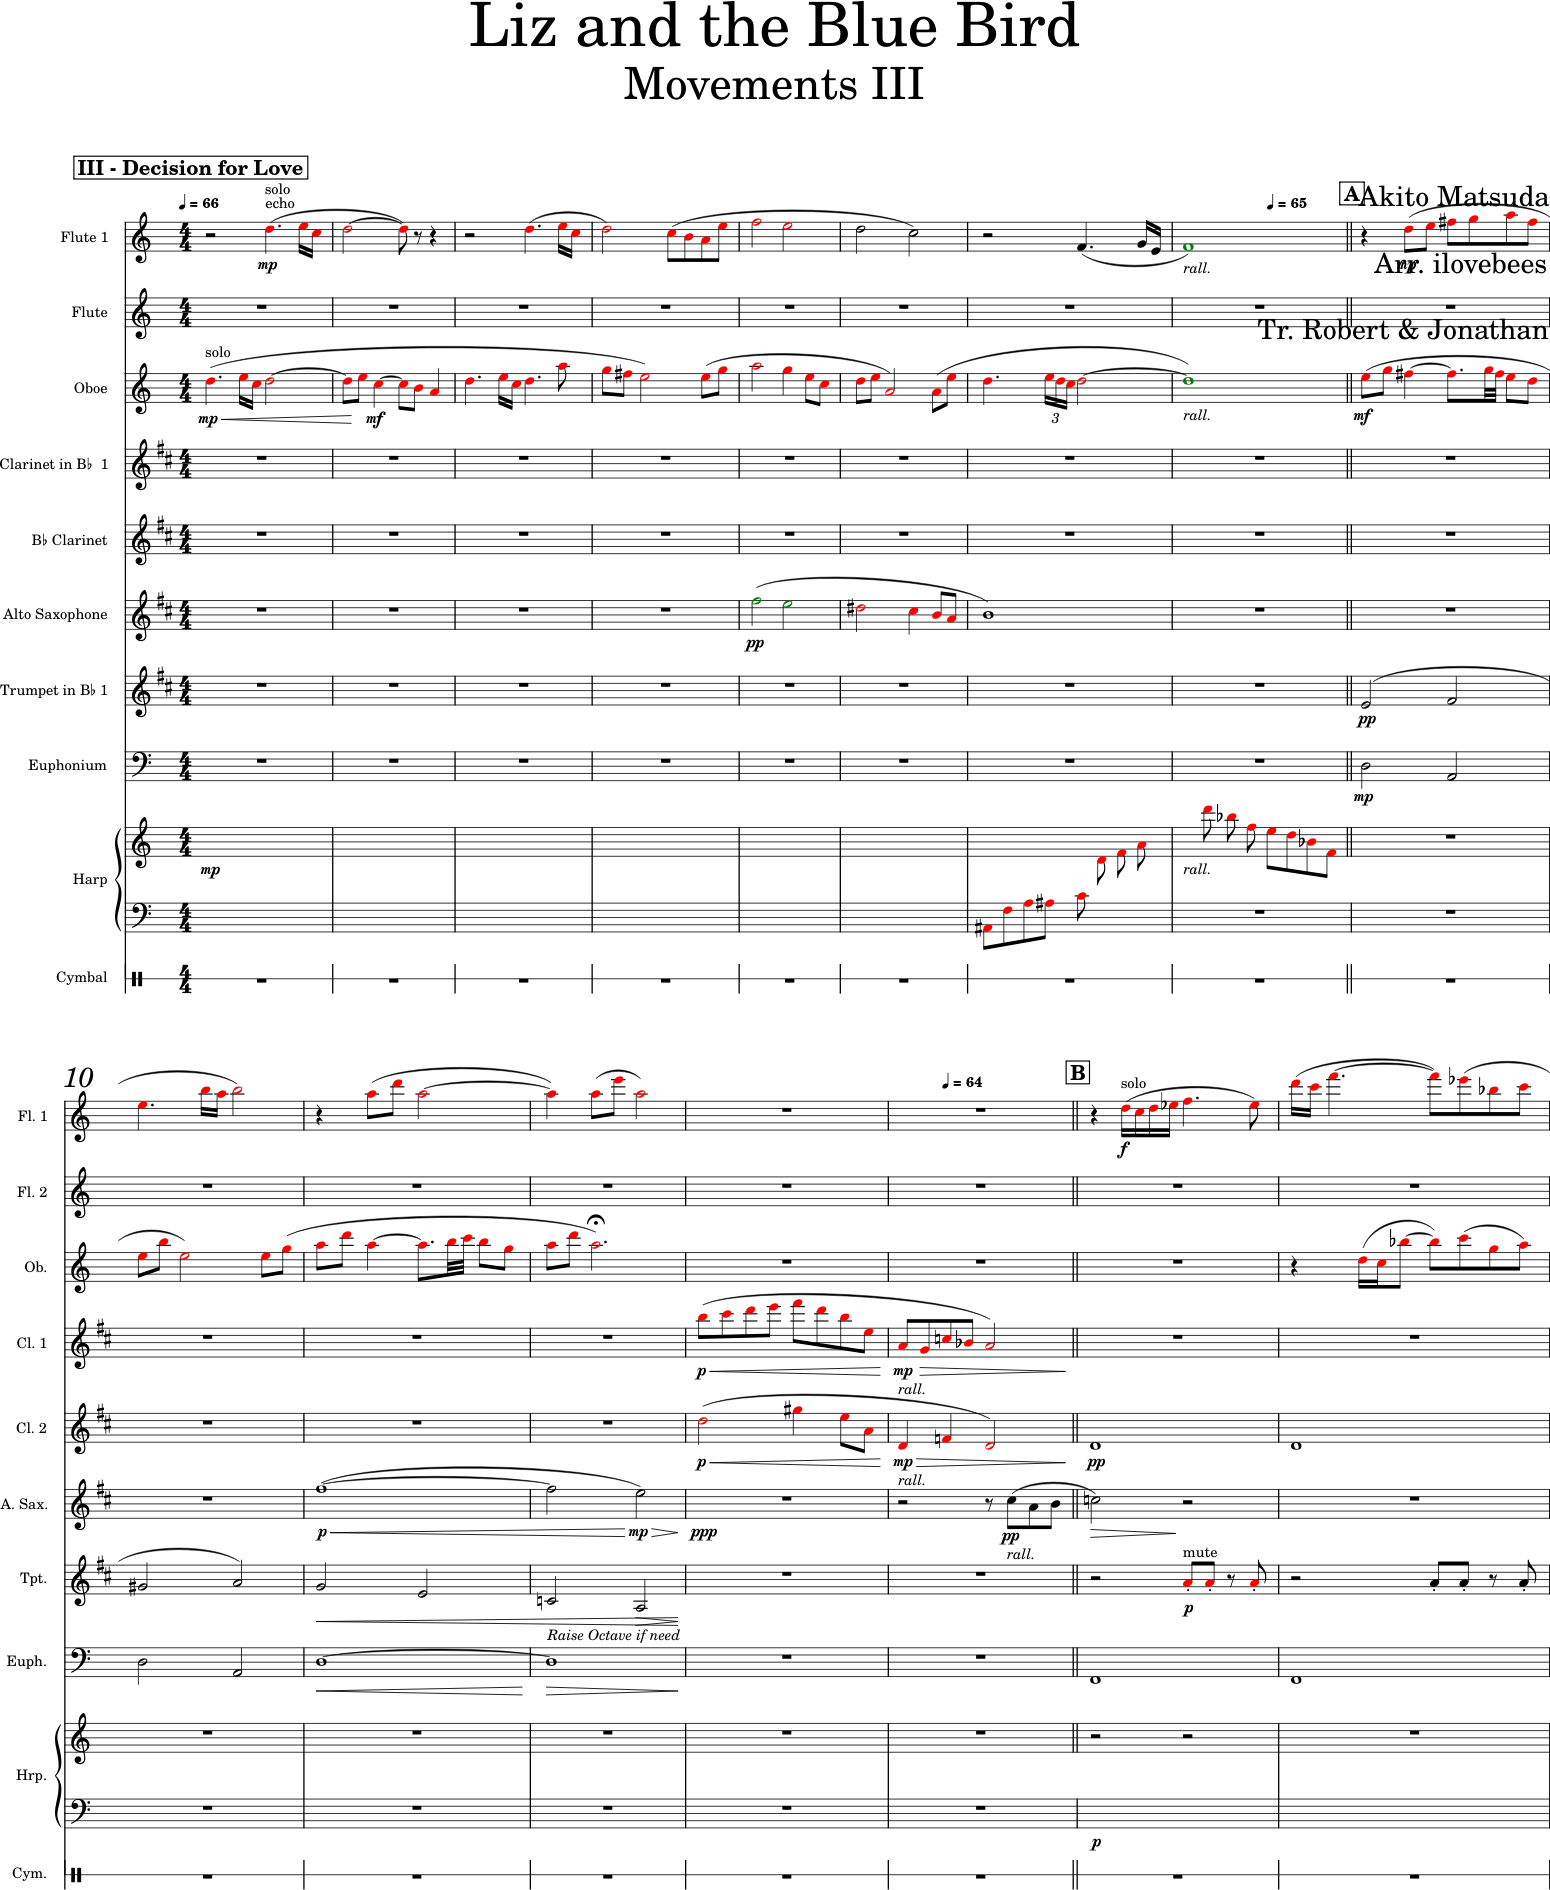

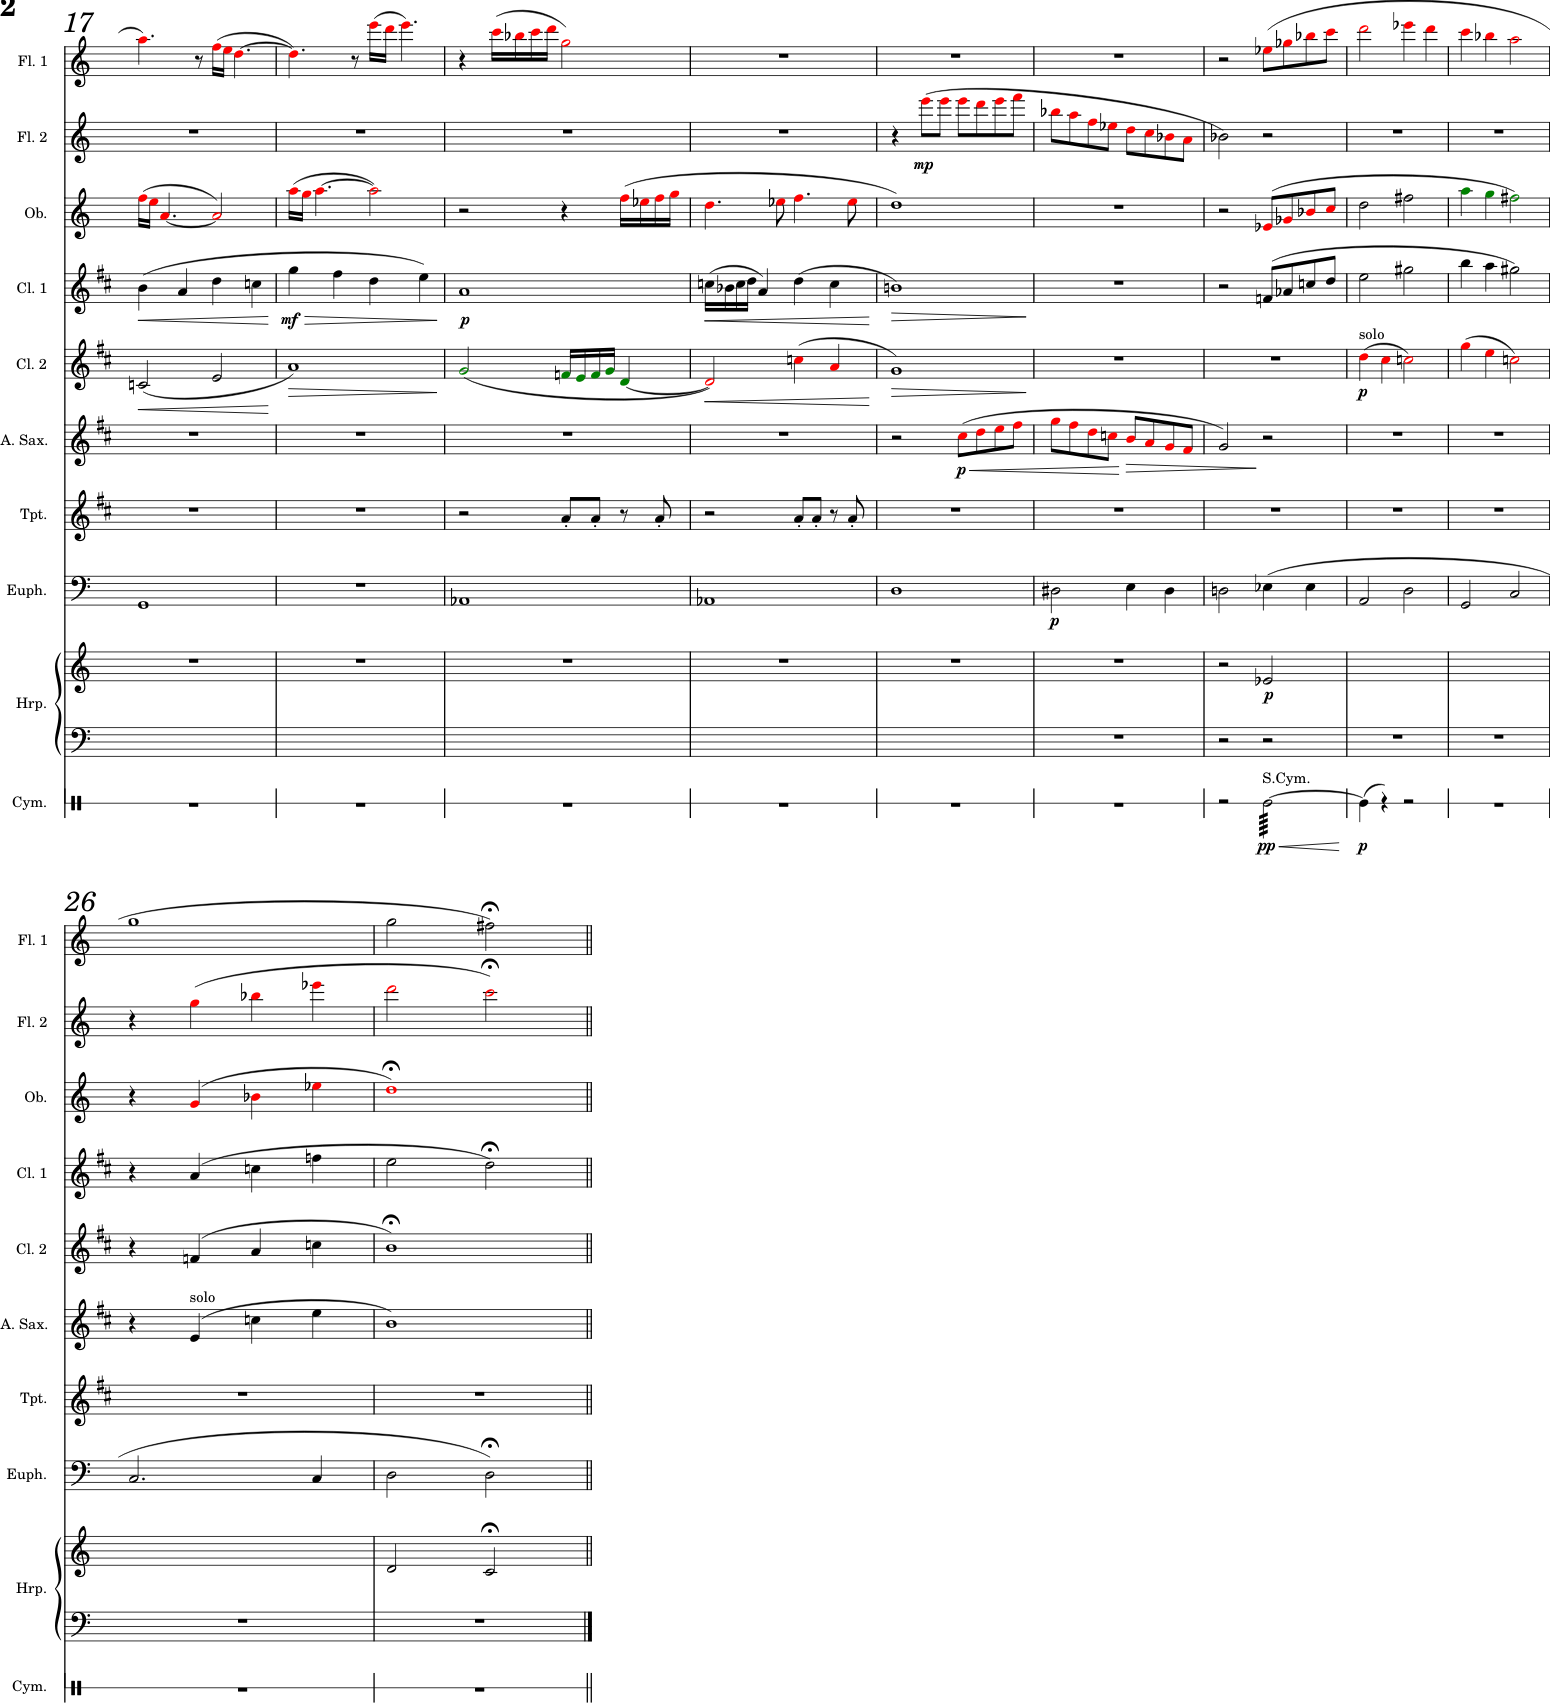

In [173]:
copyScore2.show()